In [1]:
import awkward as ak
import numpy as np
import uproot

In [34]:
import os

outputpath={
    'ZpToHGamma': '../output/ZpToHGamma/',
    'GJets': '../output/GJets/',
}
output = {
    k: ak.concatenate([ak.from_parquet(v+file) for file in os.listdir(v)]) for (k,v) in outputpath.items()
}

output

/home/pku/fudawei/.local/lib/python3.8/site-packages/awkward/operations/convert.py:1960: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if distutils.version.LooseVersion(
/home/pku/fudawei/.local/lib/python3.8/site-packages/awkward/operations/convert.py:1962: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  ) < distutils.version.LooseVersion("2.0.0"):


{'ZpToHGamma': <Array [{AK8jet_msoftdrop: [, ... ] type='180054 * {"AK8jet_msoftdrop": var * fl...'>,
 'GJets': <Array [{AK8jet_msoftdrop: [, ... ] type='149266 * {"AK8jet_msoftdrop": var * fl...'>}

In [35]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep as hep
import boost_histogram as bh
from cycler import cycler

use_helvet = False ## true: use helvetica for plots, make sure the system have the font installed
if use_helvet:
    CMShelvet = hep.style.CMS
    CMShelvet['font.sans-serif'] = ['Helvetica', 'Arial']
    plt.style.use(CMShelvet)
else:
    plt.style.use(hep.style.CMS)

mpl.rcParams['axes.prop_cycle'] = cycler(color=['red', 'blue', 'green', 'cyan', 'darkorange', 'black', 'darkviolet', 'SlateGray', 'HotPink', 'LightSkyBlue'])

In [57]:
for m in [800, 1600, 2400, 3500]:
    cut = ak.flatten(
        (output['ZpToHGamma']["gen_Z'_mass"] > m-10) &
        (output['ZpToHGamma']["gen_Z'_mass"] < m+10)
    )
    output[f'ZpToHGamma_{m}'] = output['ZpToHGamma'][cut]

del output['ZpToHGamma']

In [84]:
def plot(events: dict, variable: str, latex: str, flatten=False, bins=40, x_min=0, x_max=2000, density=True, stack=False, year=2018):
    ## canvas initializing
    #colorlist=['red', 'blue', 'green', 'black', 'cyan', 'darkorange', 'darkviolet', 'SlateGray', 'HotPink', 'LightSkyBlue']
    #mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)
    #f, ax = plt.subplots()
    plt.figure(figsize=(8,8))
    ax=plt.gca()
    plt.grid()
    hep.cms.label(data=False, year=year, ax=ax)
    
    
    ## plot
    for (k,v) in events.items():
        hist = bh.Histogram(bh.axis.Regular(bins, x_min, x_max), storage=bh.storage.Weight())
        values = ak.flatten(v[variable], axis=1) if flatten else v[variable]
        values = ak.fill_none(values, -999)
        
        if variable.startswith('gen'):
            values = ak.fill_none(values, value=-999)
        hist.fill(values)
        h, err = hist.view().value, np.sqrt(hist.view().variance)
        hep.histplot(h, bins=hist.axes[0].edges, yerr=err, label=k, histtype='step', density=density, stack=stack)
        # or you can specify color='blue' in the above function to cover colorlist (you could comment out colorlist too) 


    ## axises
    plt.xlim(x_min, x_max)
    plt.ylim(0, ax.get_ylim()[1]*1.1)
    ax.ticklabel_format(useOffset=False, style='plain')
    #x_major_locator=plt.MultipleLocator(bin_width*8 if variable=='fj_gen_mass' else bin_width*2)
    #y_major_locator=MultipleLocator(1)
    #ax.xaxis.set_major_locator(x_major_locator)
    #ax.yaxis.set_major_locator(y_major_locator)
    if density==False:
        plt.ylabel('Events', fontsize=20, ha='right', y=1)
    elif density==True:    
        plt.ylabel('A.U.', fontsize=20, ha='right', y=1)
    plt.xlabel(latex, fontsize=22, ha='right', x=1)

    plt.xticks(size=16)
    plt.yticks(size=16)


    ## title, text and legend
    #plt.title('ROC Curve of HWW4q vs. QCD', fontsize=24,color="black")
    plt.legend(loc="best", ncol=1, frameon=False, fontsize=20)
    #plt.text(0.96*ax.get_xlim()[1], ax.get_ylim()[1]*0.72,"At "+r"$\mathrm{m^{gen}_{H}=}$"+f"{Higgsmass} GeV", fontsize=24, color="black", ha='right')


    ## finalizing
    suffix = ''
    if density==True:   suffix += '_AU'
    if stack==True:     suffix += '_stack'
    plt.savefig("./plots/"+variable+suffix+".pdf", bbox_inches='tight')
    plt.show()

In [85]:
print(output['ZpToHGamma_800'].fields)

['AK8jet_msoftdrop', 'AK8jet_mass', 'AK8jet_phi', 'AK8jet_pt', 'AK8jet_eta', 'photon_pt', 'photon_mass', 'photon_eta', 'photon_phi', 'event_MET_pt', 'photon-jet_pt', 'photon-jet_mass', 'photon-jet_eta', 'photon-jet_phi', 'photon-jet_deltaR', "gen_Z'_pdgId", "gen_Z'_mass", "gen_Z'_phi", "gen_Z'_pt", "gen_Z'_eta", 'gen_H_pdgId', 'gen_H_mass', 'gen_H_phi', 'gen_H_pt', 'gen_H_eta', 'gen_a_pdgId', 'gen_a_mass', 'gen_a_phi', 'gen_a_pt', 'gen_a_eta', 'gen_WW_pdgId', 'gen_WW_mass', 'gen_WW_phi', 'gen_WW_pt', 'gen_WW_eta', 'gen_WW_childs_pdgId', 'gen_WW_childs_mass', 'gen_WW_childs_phi', 'gen_WW_childs_pt', 'gen_WW_childs_eta', 'gen_H_a', 'gen_deltaR_H_a', 'gen_HWW_decay_mode', 'gen_HWW_a', 'gen_MET_pt']


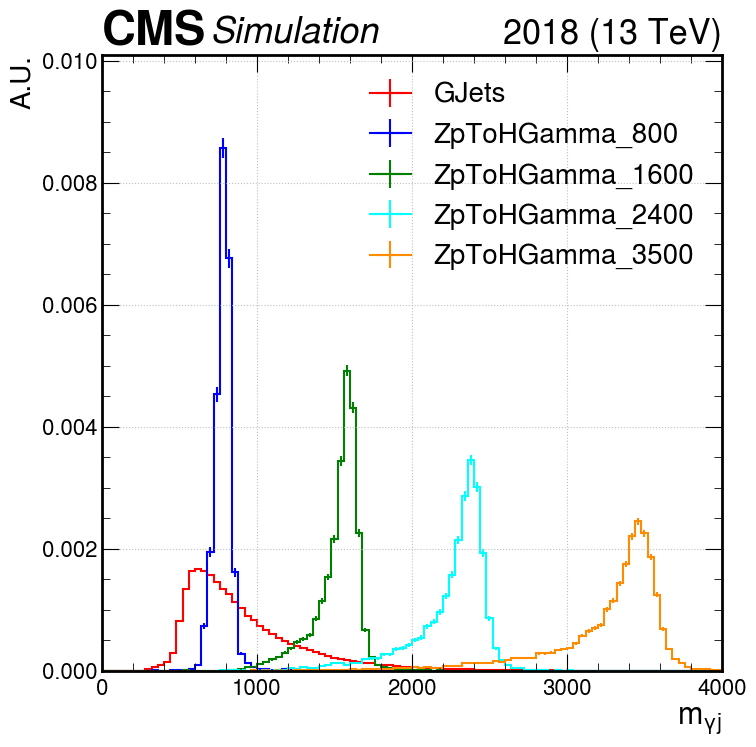

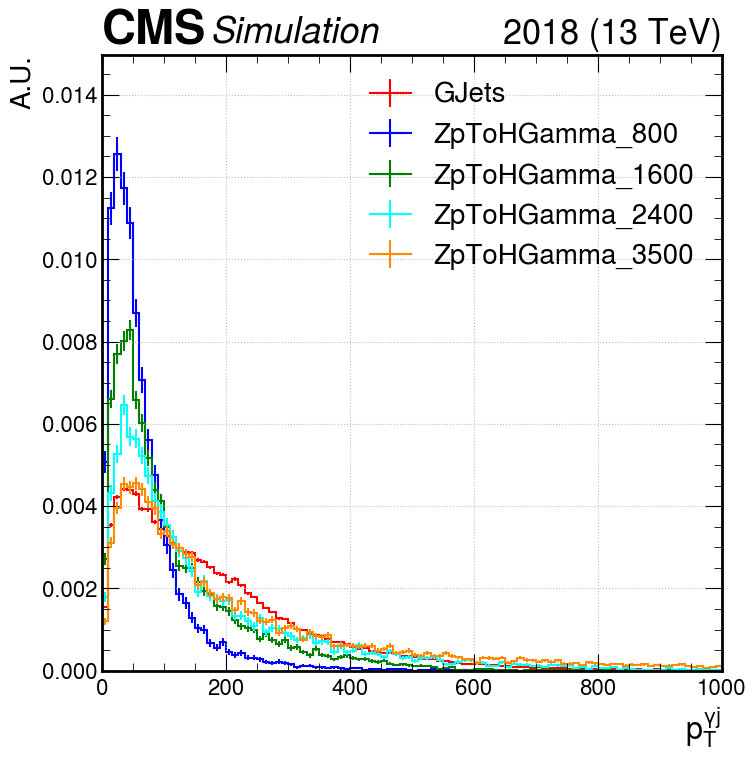

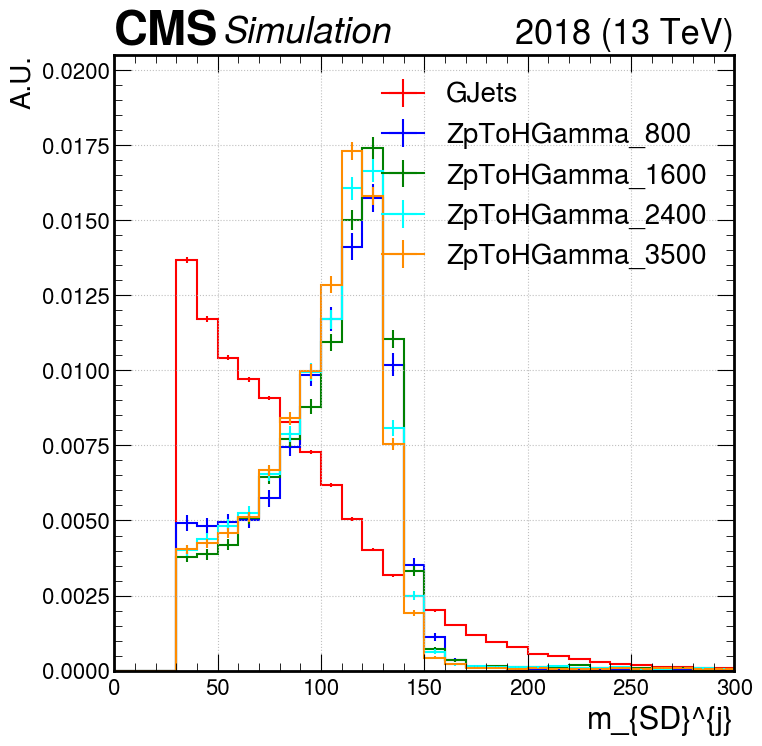

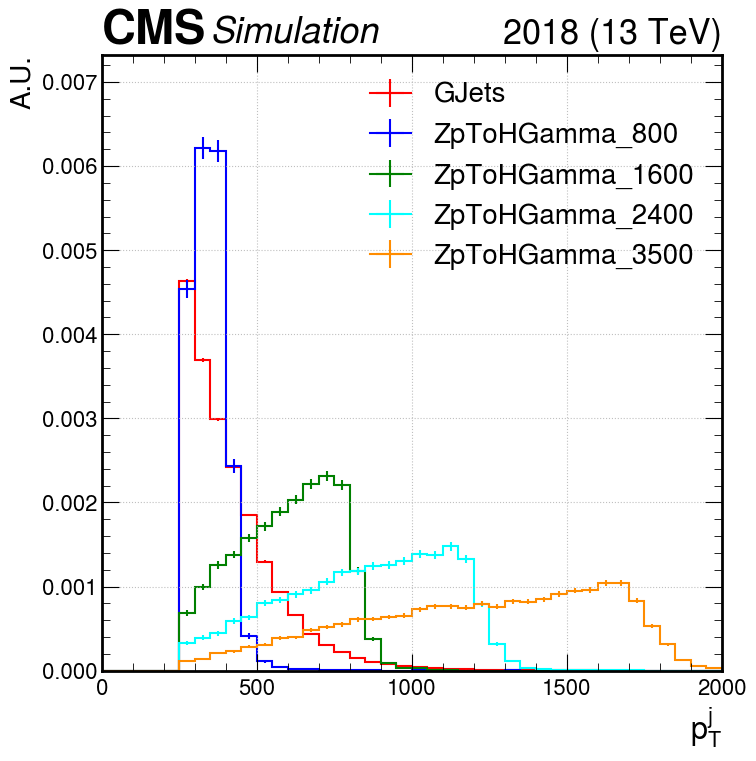

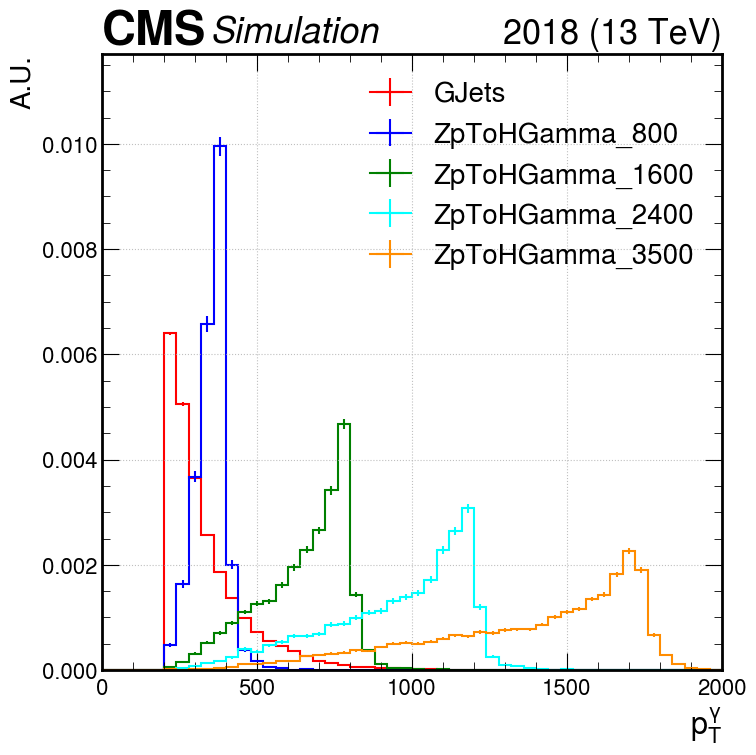

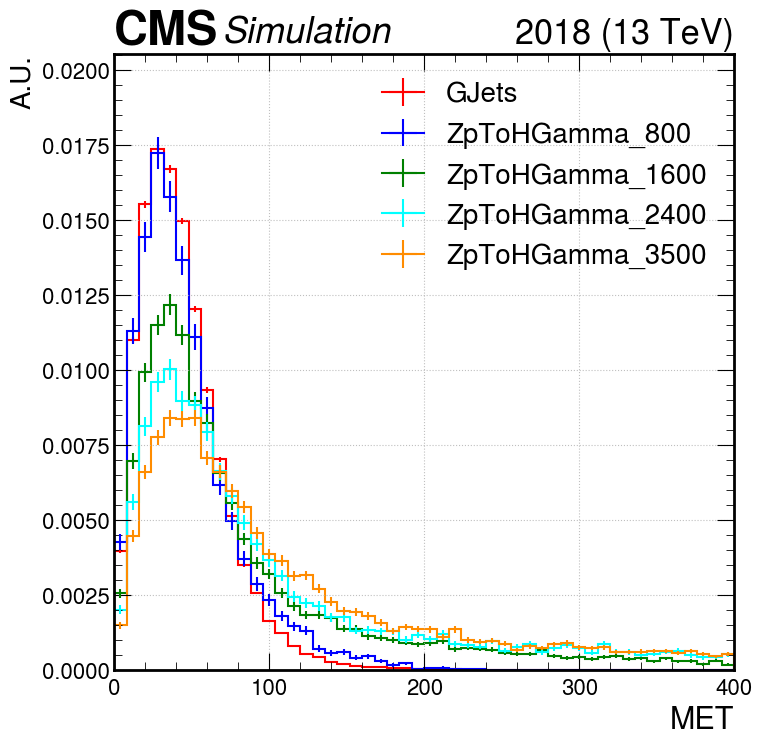

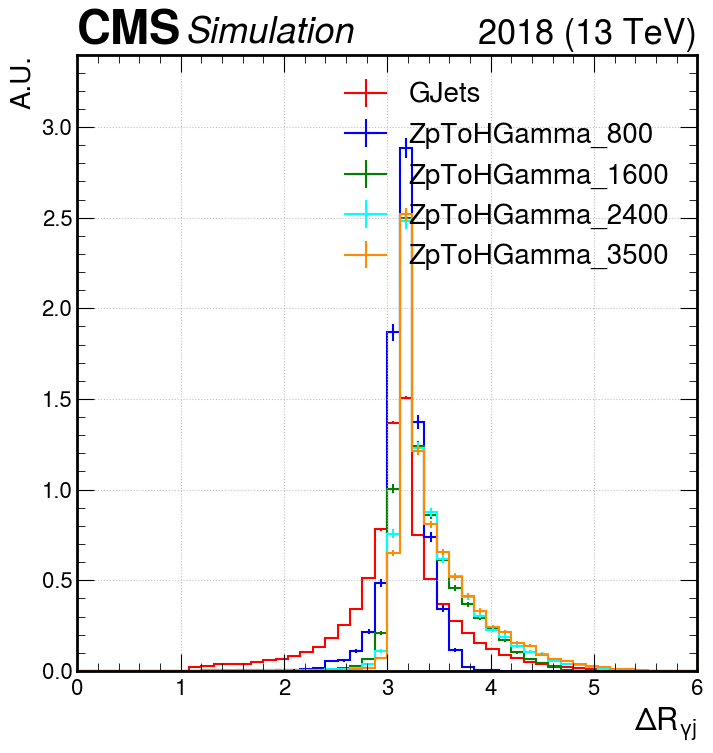

In [86]:
plot(events=output, variable='photon-jet_mass', latex=r'$m_{\gamma j}$', flatten=False, bins=100, x_min=0, x_max=4000, density=True, stack=False, year=2018)
plot(events=output, variable='photon-jet_pt', latex=r'$p_T^{\gamma j}$', flatten=False, bins=100, x_min=0, x_max=1000, density=True, stack=False, year=2018)
plot(events=output, variable='AK8jet_msoftdrop', latex=r'm_{SD}^{j}', flatten=True, bins=30, x_min=0, x_max=300, density=True, stack=False, year=2018)
plot(events=output, variable='AK8jet_pt', latex=r'$p_T^j$', flatten=True, bins=40, x_min=0, x_max=2000, density=True, stack=False, year=2018)
plot(events=output, variable='photon_pt', latex=r'$p_T^\gamma$', flatten=True, bins=50, x_min=0, x_max=2000, density=True, stack=False, year=2018)
plot(events=output, variable='event_MET_pt', latex='MET', flatten=False, bins=50, x_min=0, x_max=400, density=True, stack=False, year=2018)
plot(events=output, variable='photon-jet_deltaR', latex=r'$\Delta R_{\gamma j}$', flatten=False, bins=50, x_min=0, x_max=6, density=True, stack=False, year=2018)